# Bank Finance Report

**Report Date:** 2024-12-31 | **Currency:** PLN | **Audience:** Finance / Treasury

---
| # | Section |
|---|---|
| — | Executive P&L Summary |
| 1 | Interest Income & Expense Waterfall |
| 2 | Product Margin Analysis |
| 3 | Funding Cost Structure |
| 4 | Fixed vs Variable Rate Exposure |
| 5 | NII Bridge — Locked Interest vs Renewal |
| 6 | Repricing Profile |
| 7 | Rate Sensitivity (Business View) |
| 8 | Economic Profit (EP) — Total & Per-Product |


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import create_engine, text

ENGINE = create_engine(
    'mssql+pyodbc://maciek_d/bank_gen'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&Trusted_Connection=yes',
    future=True,
)
REPORT_DATE = pd.to_datetime('2024-12-31')
CCY = 'PLN'

plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.size': 9, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlepad': 8, 'legend.fontsize': 8, 'legend.framealpha': 0.8,
})

C_INC = '#2E7D32'; C_EXP = '#C62828'; C_NET = '#1565C0'
C_REN = '#0288D1'; C_FIX = '#1B5E20'; C_VAR = '#F57F17'
C_ADM = '#78909C'; C_GR  = '#455A64'

PRODUCT_COLORS = {
    'Mortgage Fixed':       '#1565C0',
    'Mortgage Float':       '#42A5F5',
    'Consumer Loan Fixed':  '#2E7D32',
    'Consumer Loan Float':  '#66BB6A',
    'Bond / Securities':    '#F57F17',
    'Interbank / Other':    '#78909C',
    'Term Deposit':         '#B71C1C',
    'Savings Account':      '#EF5350',
    'Current Account':      '#FF8A65',
    'Issued Bond':          '#8D6E63',
}

def rsql(q, **p):
    return pd.read_sql_query(text(q), ENGINE, params=p)

def tkey(lbl):
    if lbl == '1D':   return 0
    if lbl == '>30Y': return 999_999
    if lbl.endswith('Y'): return int(lbl[:-1]) * 12
    if lbl.endswith('M'): return int(lbl[:-1])
    return 99_999

def pct_fmt(v, _=None): return f'{v:.1f}%'

PROD_LABELS = {
    '0000': 'Interbank / Other',
    '1000': 'Mortgage Fixed',        '1100': 'Mortgage Float',
    '2000': 'Consumer Loan Fixed',   '2100': 'Consumer Loan Float',
    '3000': 'Bond / Securities',     '3100': 'Bond / Securities',
    '3200': 'T-Bill',                '3500': 'Cash / Central Bank',
    '4100': 'SME Investment Loan',   '5000': 'Issued Bond',
    '6000': 'Current Account',       '6300': 'Current Account (SME)',
    '7060': 'Term Deposit',          '7900': 'Interbank Placement',
    '8000': 'Savings Account',
}

print(f'Setup complete  |  {REPORT_DATE.date()}  |  {CCY}')


Setup complete  |  2024-12-31  |  PLN


## Data Loading

In [2]:
RD = REPORT_DATE

# 1. Actual book balances per product
bs_prod = rsql('''
    SELECT product_code, product_name, bs_side, currency,
           SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd AND currency = :ccy
    GROUP BY product_code, product_name, bs_side, currency
''', rd=RD, ccy=CCY)

equity_amt = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

# 2. NII by product — CF base scenario (consistent fixed pipeline)
nii_prod = rsql('''
    SELECT product_code, bs_side, rate_type,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM cf.nii_base_scenario
    WHERE report_date = :rd AND currency = :ccy AND scenario_id = 'base'
    GROUP BY product_code, bs_side, rate_type
''', rd=RD, ccy=CCY)

# 3. Balance-weighted average rates per product
rate_prod = rsql('''
    SELECT product_code, bs_side,
           SUM(beh_outstanding * client_rt)    / NULLIF(SUM(beh_outstanding), 0) AS avg_client_rt,
           SUM(beh_outstanding * margin)        / NULLIF(SUM(beh_outstanding), 0) AS avg_margin,
           SUM(beh_outstanding * ren_client_rt) / NULLIF(SUM(beh_outstanding), 0) AS avg_ren_rt
    FROM cf.nii_base_scenario
    WHERE report_date = :rd AND currency = :ccy AND scenario_id = 'base'
      AND beh_outstanding > 0
    GROUP BY product_code, bs_side
''', rd=RD, ccy=CCY)

# 4. Scenario NII for rate sensitivity
nii_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM irrbb.nii_results WHERE report_date=:rd AND currency=:ccy
    GROUP BY scenario_id, currency
''', rd=RD, ccy=CCY)

# 5. Repricing gap
try:
    ir_gap = rsql('''
        SELECT currency, tenor_bucket, bucket_start_dt, bucket_end_dt,
               gap_cf, ISNULL(gap_cf_ca, 0) AS gap_cf_ca
        FROM irrbb.ir_gap_beh WHERE currency = :ccy
    ''', ccy=CCY)
except Exception:
    ir_gap = rsql('''
        SELECT currency, tenor_bucket, bucket_start_dt, bucket_end_dt,
               gap_cf, 0.0 AS gap_cf_ca
        FROM irrbb.ir_gap_beh WHERE currency = :ccy
    ''', ccy=CCY)

# ── Master product table ──────────────────────────────────────────────────────
prod = (nii_prod
        .merge(rate_prod, on=['product_code','bs_side'], how='left')
        .merge(bs_prod[['product_code','bs_side','balance_amt']], on=['product_code','bs_side'], how='left'))
prod['label']       = prod['product_code'].map(PROD_LABELS).fillna(prod['product_code'])
prod['balance_amt'] = prod['balance_amt'].fillna(0.0)
assets_p = prod[prod['bs_side'] == 'A'].copy()
liabs_p  = prod[prod['bs_side'] == 'L'].copy()

# ── Key aggregate metrics ─────────────────────────────────────────────────────
total_assets   = float(bs_prod[bs_prod['bs_side']=='A']['balance_amt'].sum())
total_liabs    = float(bs_prod[bs_prod['bs_side']=='L']['balance_amt'].sum())
total_inc      = float(assets_p['nii_interest'].sum())
total_exp      = abs(float(liabs_p['nii_interest'].sum()))
nii_total      = total_inc - total_exp
nim_pct        = nii_total  / total_assets * 100 if total_assets else 0
avg_asset_yld  = total_inc  / total_assets * 100 if total_assets else 0
avg_cost_funds = total_exp  / total_liabs  * 100 if total_liabs  else 0
int_spread     = avg_asset_yld - avg_cost_funds

print(f'  Total assets     {total_assets/1e9:>8.2f}  B PLN')
print(f'  Total liabilities{total_liabs/1e9:>8.2f}  B PLN')
print(f'  Interest income  {total_inc/1e6:>8.1f}  M PLN')
print(f'  Interest expense {total_exp/1e6:>8.1f}  M PLN')
print(f'  NII              {nii_total/1e6:>8.1f}  M PLN')
print(f'  NIM              {nim_pct:>8.2f}  %')
print(f'  Avg asset yield  {avg_asset_yld:>8.2f}  %')
print(f'  Cost of funds    {avg_cost_funds:>8.2f}  %')
print(f'  Spread           {int_spread:>8.2f}  %')


  Total assets        10.00  B PLN
  Total liabilities    8.80  B PLN
  Interest income     776.9  M PLN
  Interest expense    151.1  M PLN
  NII                 625.7  M PLN
  NIM                  6.26  %
  Avg asset yield      7.77  %
  Cost of funds        1.72  %
  Spread               6.05  %


---
## Executive P&L Summary


In [3]:
SEP  = '=' * 62
SEP2 = '-' * 62

_base_nii_off = float(nii_scen[nii_scen['scenario_id']=='base']['nii_total'].sum())                 if not nii_scen.empty else nii_total

print(f'\n{SEP}')
print(f'  FINANCE P&L SUMMARY  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'{SEP}')
print(f'  BALANCE SHEET')
print(f'    Total assets             {total_assets/1e9:>9.2f}  B PLN')
print(f'    Total liabilities        {total_liabs/1e9:>9.2f}  B PLN')
print(f'    Equity                   {equity_amt/1e9:>9.2f}  B PLN')
print(f'{SEP2}')
print(f'  INTEREST INCOME & EXPENSE  (1-year horizon, existing book)')
print(f'    Interest income (assets) {total_inc/1e6:>+9.1f}  M PLN')
print(f'    Interest expense (liab.) {-total_exp/1e6:>+9.1f}  M PLN')
print(f'    Net Interest Income      {nii_total/1e6:>+9.1f}  M PLN')
print(f'{SEP2}')
print(f'  MARGIN METRICS')
print(f'    Net Interest Margin      {nim_pct:>9.2f}  %    (NII / total assets)')
print(f'    Avg asset yield          {avg_asset_yld:>9.2f}  %')
print(f'    Avg cost of funds        {avg_cost_funds:>9.2f}  %')
print(f'    Interest spread          {int_spread:>9.2f}  %')
print(f'{SEP2}')
_fa = prod[(prod['bs_side']=='A') & (prod['rate_type']=='F')]['balance_amt'].sum()
_va = prod[(prod['bs_side']=='A') & (prod['rate_type']=='V')]['balance_amt'].sum()
_fl = prod[(prod['bs_side']=='L') & (prod['rate_type']=='F')]['balance_amt'].sum()
_vl = prod[(prod['bs_side']=='L') & (prod['rate_type']=='V')]['balance_amt'].sum()
_al = prod[(prod['bs_side']=='L') & (prod['rate_type']=='A')]['balance_amt'].sum()
print(f'  RATE TYPE MIX  (by balance)')
print(f'    Assets     Fixed {_fa/total_assets*100:>5.0f}%   Variable {_va/total_assets*100:>5.0f}%')
print(f'    Liabilities Fixed {_fl/total_liabs*100:>5.0f}%  Variable {_vl/total_liabs*100:>5.0f}%  Admin {_al/total_liabs*100:>5.0f}%')
print(f'{SEP2}')
print(f'  EBA PARALLEL SHOCK SENSITIVITY')
for _s, _lbl in [('par_up','+250 bps'),('par_dn','-250 bps')]:
    _r = nii_scen[nii_scen['scenario_id']==_s]
    if _r.empty: continue
    _v = float(_r['nii_total'].sum()); _d = _v - _base_nii_off
    print(f'    {_lbl:<12}  ΔNII {_d/1e6:>+8.1f} M PLN  ({_d/_base_nii_off*100:>+.1f}%)')
print(f'{SEP}')



  FINANCE P&L SUMMARY  |  PLN  |  2024-12-31
  BALANCE SHEET
    Total assets                 10.00  B PLN
    Total liabilities             8.80  B PLN
    Equity                        1.20  B PLN
--------------------------------------------------------------
  INTEREST INCOME & EXPENSE  (1-year horizon, existing book)
    Interest income (assets)    +776.9  M PLN
    Interest expense (liab.)    -151.1  M PLN
    Net Interest Income         +625.7  M PLN
--------------------------------------------------------------
  MARGIN METRICS
    Net Interest Margin           6.26  %    (NII / total assets)
    Avg asset yield               7.77  %
    Avg cost of funds             1.72  %
    Interest spread               6.05  %
--------------------------------------------------------------
  RATE TYPE MIX  (by balance)
    Assets     Fixed    28%   Variable    70%
    Liabilities Fixed    20%  Variable    36%  Admin    43%
--------------------------------------------------------------
  EB

---
## 1. Interest Income & Expense Waterfall

Gross interest income stacked by asset product, gross interest expense by liability product, resulting in NII.


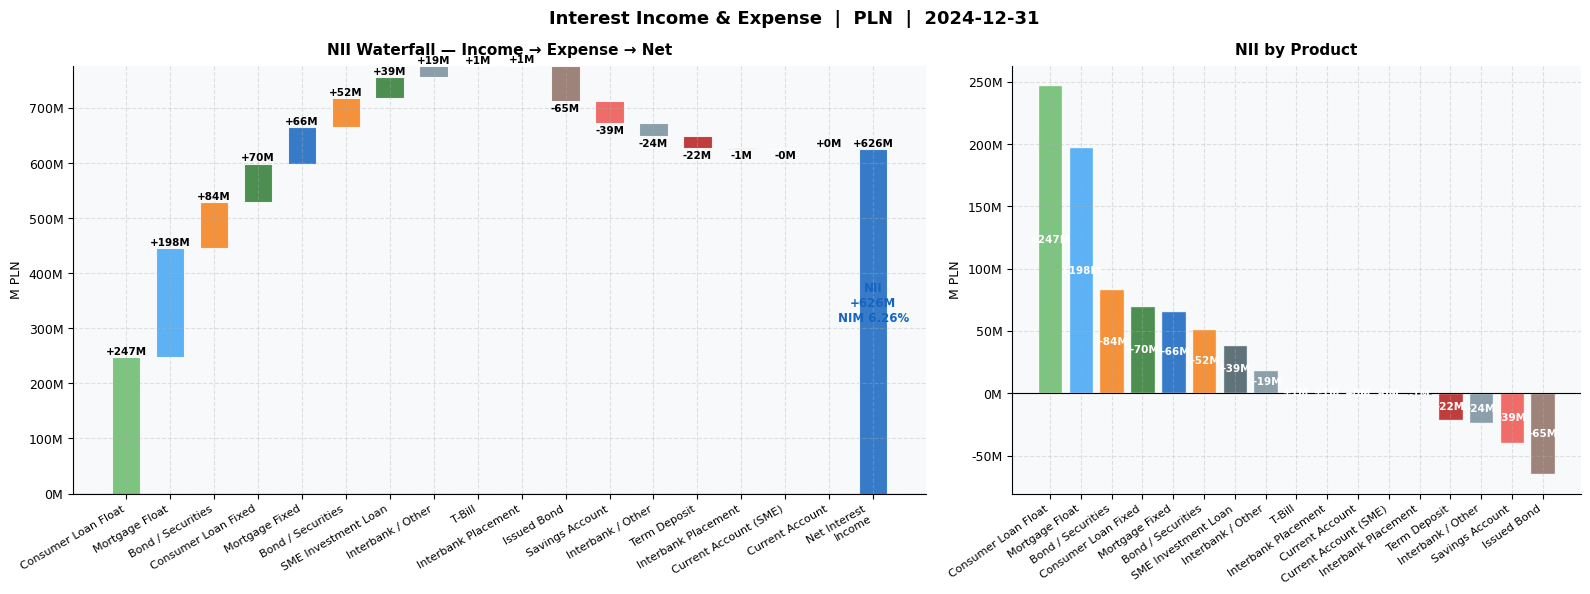

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={'width_ratios': [1.5, 1]})
fig.suptitle(f'Interest Income & Expense  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# ── Waterfall ─────────────────────────────────────────────────────────────────
wf_labels, wf_vals, wf_bots, wf_cols = [], [], [], []
running = 0.0
for _, row in assets_p.sort_values('nii_interest', ascending=False).iterrows():
    wf_labels.append(row['label']); wf_vals.append(row['nii_interest']/1e6)
    wf_bots.append(running/1e6);    wf_cols.append(PRODUCT_COLORS.get(row['label'], C_INC))
    running += row['nii_interest']
for _, row in liabs_p.sort_values('nii_interest').iterrows():
    wf_labels.append(row['label']); wf_vals.append(row['nii_interest']/1e6)
    wf_bots.append(running/1e6);    wf_cols.append(PRODUCT_COLORS.get(row['label'], C_EXP))
    running += row['nii_interest']
wf_labels.append('Net Interest\nIncome'); wf_vals.append(nii_total/1e6)
wf_bots.append(0.0);                      wf_cols.append(C_NET)

x1 = np.arange(len(wf_labels))
bars1 = ax1.bar(x1, wf_vals, bottom=wf_bots, color=wf_cols,
                alpha=0.85, edgecolor='white', linewidth=0.8, width=0.65)
for bar, val in zip(bars1, wf_vals):
    ypos = bar.get_y() + bar.get_height() + (1.5 if val >= 0 else -3.5)
    ax1.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.0f}M',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=7.5, fontweight='bold')
ax1.set_xticks(x1); ax1.set_xticklabels(wf_labels, rotation=30, ha='right', fontsize=8)
ax1.axhline(0, color='black', lw=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax1.set_ylabel('M PLN'); ax1.set_title('NII Waterfall — Income → Expense → Net')
ax1.text(len(x1)-1, nii_total/1e6*0.5,
         f'NII\n{nii_total/1e6:+.0f}M\nNIM {nim_pct:.2f}%',
         ha='center', fontsize=8.5, color=C_NET, fontweight='bold')

# ── Per-product bar ───────────────────────────────────────────────────────────
_all = pd.concat([assets_p, liabs_p]).sort_values('nii_interest', ascending=False)
x2 = np.arange(len(_all))
cols2 = [PRODUCT_COLORS.get(r['label'], C_GR) for _, r in _all.iterrows()]
b2 = ax2.bar(x2, _all['nii_interest']/1e6, color=cols2, alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(b2, _all.iterrows()):
    v = row['nii_interest']/1e6
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2 + bar.get_y(),
             f'{v:+.0f}M', ha='center', va='center',
             fontsize=7.5, color='white', fontweight='bold')
ax2.set_xticks(x2); ax2.set_xticklabels(_all['label'], rotation=35, ha='right', fontsize=8)
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax2.set_title('NII by Product'); ax2.set_ylabel('M PLN')
plt.tight_layout(); plt.show()


---
## 2. Product Margin Analysis

Effective rate on each product vs blended cost of funds (assets) or blended asset yield (liabilities).
**Spread** = how much each product contributes above/below the bank's blended benchmark.



  Benchmark: Assets vs CoF 1.72%  |  Liabilities vs Yield 7.77%
  Product                    S     Type     Bal(M)  NII Int(M)   Rate%  Bench%  Spread bps
  -----------------------------------------------------------------------------------------------
  Consumer Loan Float        A Variable      1,800      +247.4   13.74    1.72       +1202
  Mortgage Float             A Variable      2,800      +197.8    7.07    1.72        +535
  Bond / Securities          A Variable      1,600       +83.9    5.24    1.72        +352
  Consumer Loan Fixed        A    Fixed        600       +70.0   11.67    1.72        +995
  Mortgage Fixed             A    Fixed      1,000       +66.4    6.64    1.72        +492
  Bond / Securities          A    Fixed        800       +51.9    6.48    1.72        +477
  SME Investment Loan        A Variable        600       +39.1    6.52    1.72        +481
  Interbank / Other          A    Fixed          0       +18.9    0.00    1.72        -172  **
  T-Bill      

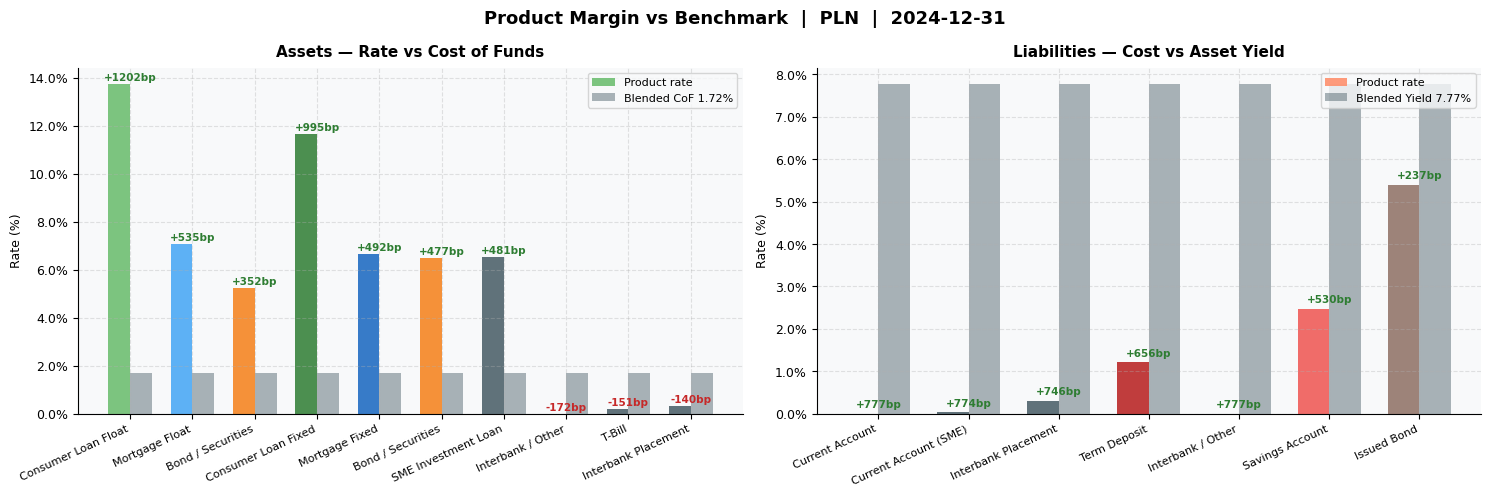

In [5]:
blended_cof = avg_cost_funds / 100
blended_yld = avg_asset_yld  / 100

rows = []
for _, r in prod.sort_values(['bs_side','nii_interest'], ascending=[True,False]).iterrows():
    bal   = r['balance_amt']
    nii_i = r['nii_interest']
    eff   = abs(nii_i) / bal if bal > 0 else 0.0
    spread = (eff - blended_cof) if r['bs_side']=='A' else (blended_yld - eff)
    rows.append({
        'Product':        r['label'],
        'Side':           r['bs_side'],
        'Type':           {'F':'Fixed','V':'Variable','A':'Admin'}.get(r['rate_type'], r['rate_type']),
        'Balance (M)':    round(bal/1e6, 0),
        'NII Int (M)':    round(nii_i/1e6, 1),
        'Eff. Rate (%)':  round(eff*100, 2),
        'Benchmark (%)':  round((blended_cof if r['bs_side']=='A' else blended_yld)*100, 2),
        'Spread (bps)':   round(spread*10000, 0),
    })
tbl = pd.DataFrame(rows)

hdr = '{:<25} {:>2} {:>8} {:>10} {:>11} {:>7} {:>7} {:>11}'.format(
    'Product', 'S', 'Type', 'Bal(M)', 'NII Int(M)', 'Rate%', 'Bench%', 'Spread bps')
print('\n  Benchmark: Assets vs CoF {:.2f}%  |  Liabilities vs Yield {:.2f}%'.format(
    avg_cost_funds, avg_asset_yld))
print('  ' + hdr); print('  ' + '-'*95)
for _, r in tbl.iterrows():
    spd = r['Spread (bps)']
    flag = '  **' if (r['Side']=='A' and spd < 0) or (r['Side']=='L' and spd < 0) else ''
    line = '  {:<25} {:>2} {:>8} {:>10,.0f} {:>+11.1f} {:>7.2f} {:>7.2f} {:>+11.0f}{}'.format(
        r['Product'], r['Side'], r['Type'],
        r['Balance (M)'], r['NII Int (M)'],
        r['Eff. Rate (%)'], r['Benchmark (%)'], spd, flag)
    print(line)

# Chart
fig2, (axA, axL) = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle(f'Product Margin vs Benchmark  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')
for ax, side, bench_val, bench_lbl, title in [
    (axA, 'A', avg_cost_funds, f'Blended CoF {avg_cost_funds:.2f}%', 'Assets — Rate vs Cost of Funds'),
    (axL, 'L', avg_asset_yld,  f'Blended Yield {avg_asset_yld:.2f}%', 'Liabilities — Cost vs Asset Yield'),
]:
    _s = tbl[tbl['Side']==side].reset_index(drop=True)
    if _s.empty: continue
    _x = np.arange(len(_s)); w = 0.35
    ax.bar(_x - w/2, _s['Eff. Rate (%)'],  w, label='Product rate',
           color=[PRODUCT_COLORS.get(lb, C_GR) for lb in _s['Product']], alpha=0.85)
    ax.bar(_x + w/2, [bench_val]*len(_s), w, label=bench_lbl,
           color=C_GR, alpha=0.45)
    for i, (_, row) in enumerate(_s.iterrows()):
        spd = row['Spread (bps)']
        col = C_INC if spd >= 0 else C_EXP
        ax.text(i, row['Eff. Rate (%)']+0.15, f'{spd:+.0f}bp',
                ha='center', fontsize=7.5, fontweight='bold', color=col)
    ax.set_xticks(_x); ax.set_xticklabels(_s['Product'], rotation=25, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
    ax.set_title(title); ax.set_ylabel('Rate (%)'); ax.legend()
plt.tight_layout(); plt.show()


---
## 3. Funding Cost Structure

Liability mix by balance and annual interest cost, with blended cost of funds benchmark.


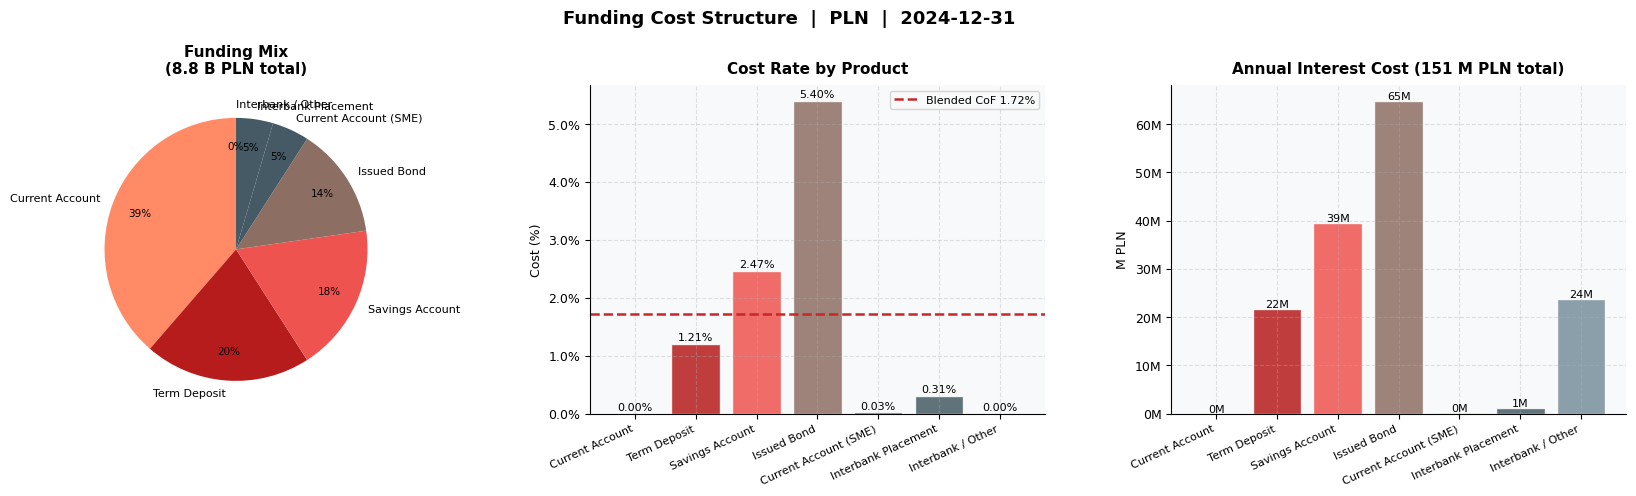


  Product                    Balance (M)   Cost (M)    Rate%   % of liabs
  ------------------------------------------------------------------------
  Current Account                  3,400        0.0     0.00        38.6%
  Term Deposit                     1,800       21.7     1.21        20.5%
  Savings Account                  1,600       39.5     2.47        18.2%
  Issued Bond                      1,200       64.8     5.40        13.6%
  Current Account (SME)              400        0.1     0.03         4.5%
  Interbank Placement                400        1.2     0.31         4.5%
  Interbank / Other                    0       23.7      nan         0.0%
  ------------------------------------------------------------------------
  TOTAL                            8,800      151.1     1.72       100.0%


In [6]:
_l = liabs_p.copy()
_l['bal_abs']  = _l['balance_amt'].abs()
_l['cost_abs'] = _l['nii_interest'].abs()
_l['eff_cost'] = _l['cost_abs'] / _l['bal_abs'].replace(0, np.nan)
_l = _l.sort_values('bal_abs', ascending=False)

fig3, axes3 = plt.subplots(1, 3, figsize=(17, 5))
fig3.suptitle(f'Funding Cost Structure  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

# Pie: funding mix
_cols_pie = [PRODUCT_COLORS.get(lb, C_GR) for lb in _l['label']]
wedges, texts, autos = axes3[0].pie(
    _l['bal_abs'], labels=_l['label'], autopct='%1.0f%%',
    colors=_cols_pie, startangle=90, pctdistance=0.78,
    textprops={'fontsize': 8})
for a in autos: a.set_fontsize(7.5)
axes3[0].set_title(f'Funding Mix\n({total_liabs/1e9:.1f} B PLN total)')

# Bar: cost rate
_x = np.arange(len(_l))
_rt = (_l['eff_cost'].fillna(0) * 100).tolist()
b_r = axes3[1].bar(_x, _rt, color=_cols_pie, alpha=0.85, edgecolor='white')
for bar, v in zip(b_r, _rt):
    axes3[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                  f'{v:.2f}%', ha='center', fontsize=8)
axes3[1].axhline(avg_cost_funds, color=C_EXP, lw=1.8, ls='--',
                 label=f'Blended CoF {avg_cost_funds:.2f}%')
axes3[1].set_xticks(_x); axes3[1].set_xticklabels(_l['label'], rotation=25, ha='right', fontsize=8)
axes3[1].yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
axes3[1].set_title('Cost Rate by Product'); axes3[1].set_ylabel('Cost (%)'); axes3[1].legend()

# Bar: annual cost M PLN
_cm = (_l['cost_abs']/1e6).tolist()
b_c = axes3[2].bar(_x, _cm, color=_cols_pie, alpha=0.85, edgecolor='white')
for bar, v in zip(b_c, _cm):
    axes3[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{v:.0f}M', ha='center', fontsize=8)
axes3[2].set_xticks(_x); axes3[2].set_xticklabels(_l['label'], rotation=25, ha='right', fontsize=8)
axes3[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
axes3[2].set_title(f'Annual Interest Cost ({total_exp/1e6:.0f} M PLN total)')
axes3[2].set_ylabel('M PLN')
plt.tight_layout(); plt.show()

print(f'\n  {"Product":<25} {"Balance (M)":>12} {"Cost (M)":>10} {"Rate%":>8} {"% of liabs":>12}')
print('  '+'-'*72)
for _, r in _l.iterrows():
    print(f'  {r["label"]:<25} {r["bal_abs"]/1e6:>12,.0f} {r["cost_abs"]/1e6:>10.1f} '
          f'{(r["eff_cost"] or 0)*100:>8.2f} {r["bal_abs"]/total_liabs*100:>11.1f}%')
print('  '+'-'*72)
print(f'  {"TOTAL":<25} {total_liabs/1e6:>12,.0f} {total_exp/1e6:>10.1f} '
      f'{avg_cost_funds:>8.2f} {"100.0%":>12}')


---
## 4. Fixed vs Variable Rate Exposure

How much of the balance sheet reprices when market rates move.
`Fixed` — contractually locked. `Variable` — resets to WIBOR + spread. `Admin` — floored at 0% (e.g. current accounts).


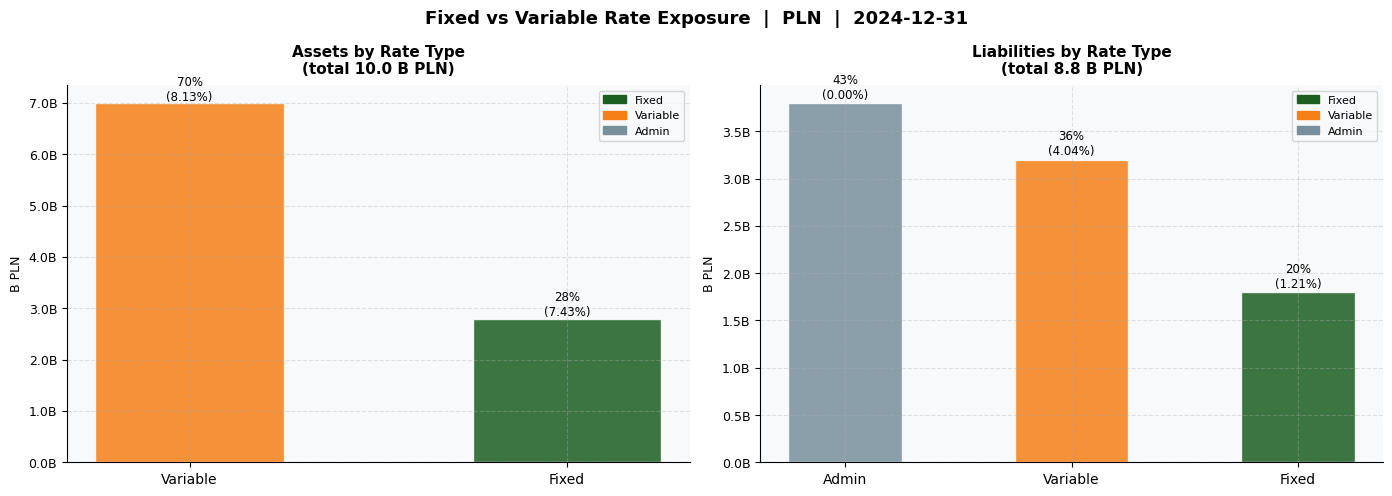


  ASSETS:
    Fixed       2.80 B PLN  ( 28.6%)  avg rate 7.43%
    Variable    7.00 B PLN  ( 71.4%)  avg rate 8.13%

  LIABILITIES:
    Fixed       1.80 B PLN  ( 20.5%)  avg rate 1.21%
    Variable    3.20 B PLN  ( 36.4%)  avg rate 4.04%
    Admin       3.80 B PLN  ( 43.2%)  avg rate 0.00%


In [7]:
fig4, (ax4a, ax4l) = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle(f'Fixed vs Variable Rate Exposure  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

RT_COLORS = {'Fixed': C_FIX, 'Variable': C_VAR, 'Admin': C_ADM}
RT_MAP    = {'F': 'Fixed', 'V': 'Variable', 'A': 'Admin'}

for ax, side, total_b, title in [
    (ax4a, 'A', total_assets, 'Assets by Rate Type'),
    (ax4l, 'L', total_liabs,  'Liabilities by Rate Type'),
]:
    _s  = prod[prod['bs_side']==side].copy()
    _grp = (_s.groupby('rate_type')
              .agg(balance=('balance_amt','sum'), nii_int=('nii_interest','sum'))
              .reset_index())
    _grp['label']    = _grp['rate_type'].map(RT_MAP)
    _grp['eff_rate'] = _grp['nii_int'].abs() / _grp['balance'].replace(0, np.nan)
    _grp = _grp.sort_values('balance', ascending=False)

    _x = np.arange(len(_grp))
    _bc = [RT_COLORS.get(lb, C_GR) for lb in _grp['label']]
    bars4 = ax.bar(_x, _grp['balance']/1e9, color=_bc, alpha=0.85,
                   edgecolor='white', width=0.5)
    for bar, (_, row) in zip(bars4, _grp.iterrows()):
        pct = row['balance'] / total_b * 100
        rate_s = f"{row['eff_rate']*100:.2f}%" if pd.notna(row['eff_rate']) else 'n/a'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{pct:.0f}%\n({rate_s})', ha='center', fontsize=8.5)
    ax.set_xticks(_x); ax.set_xticklabels(_grp['label'], fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}B'))
    ax.set_title(f'{title}\n(total {total_b/1e9:.1f} B PLN)')
    ax.set_ylabel('B PLN')
    ax.legend(handles=[mpatches.Patch(color=c,label=l) for l,c in RT_COLORS.items()])

plt.tight_layout(); plt.show()

for side, lbl in [('A','ASSETS'),('L','LIABILITIES')]:
    _s = prod[prod['bs_side']==side]; tot = _s['balance_amt'].abs().sum()
    print(f'\n  {lbl}:')
    for rt, rl in [('F','Fixed'),('V','Variable'),('A','Admin')]:
        _r = _s[_s['rate_type']==rt]
        if _r.empty: continue
        b = _r['balance_amt'].abs().sum()
        eff = abs(_r['nii_interest'].sum()) / b * 100 if b else 0
        print(f'    {rl:<10} {b/1e9:>5.2f} B PLN  ({b/tot*100:>5.1f}%)  avg rate {eff:.2f}%')


---
## 5. NII Bridge — Locked Interest vs Renewal

**Locked interest** (`nii_interest`): income from CFs already on the book — rate and amount are contractually fixed regardless of market moves.
**Renewal** (`nii_renewal`): income from maturing capital reinvested at current market rates within the 1-year horizon.

Locked NII is immune to rate shocks; renewal NII reprices at market.


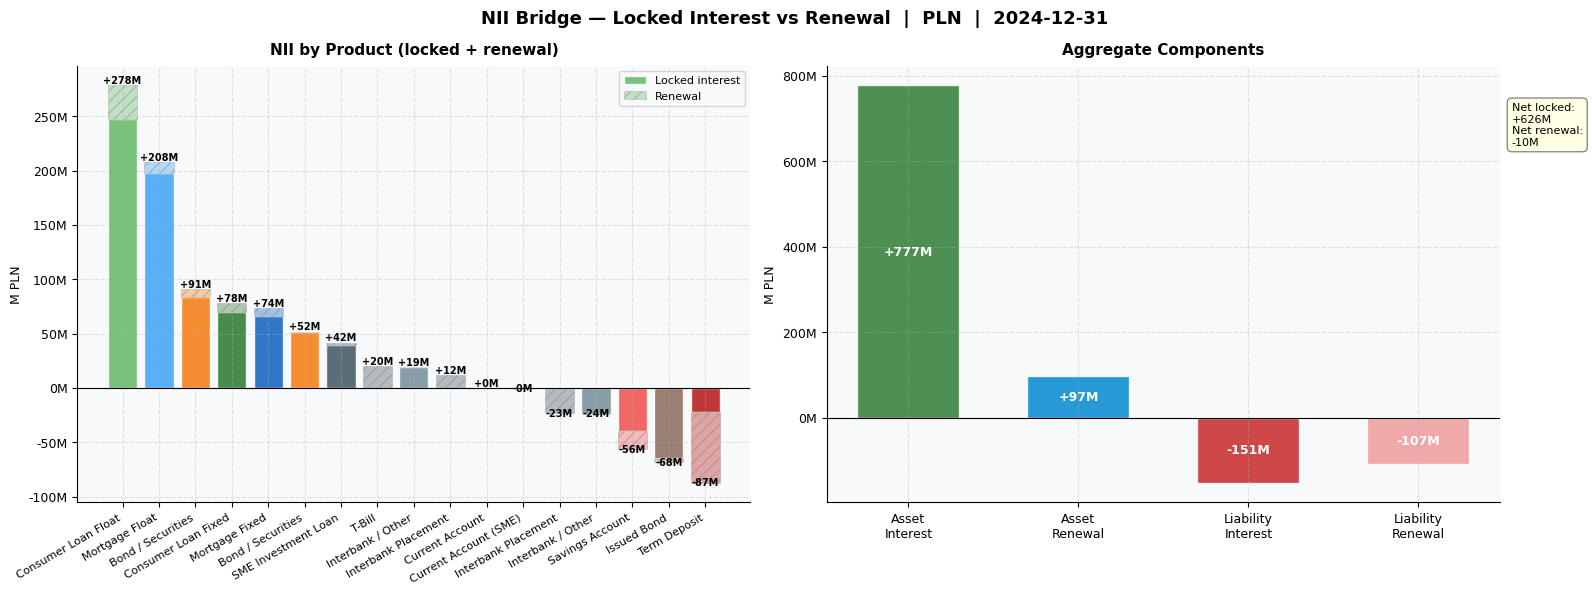


  Product (Side)                        Interest (M)   Renewal (M)    Total (M)
  ------------------------------------------------------------------------------
  Consumer Loan Float (A)                     +247.4         +31.0       +278.4
  Mortgage Float (A)                          +197.8         +10.3       +208.2
  Bond / Securities (A)                        +83.9          +7.2        +91.1
  Consumer Loan Fixed (A)                      +70.0          +8.3        +78.3
  Mortgage Fixed (A)                           +66.4          +7.1        +73.5
  Bond / Securities (A)                        +51.9          +0.0        +51.9
  SME Investment Loan (A)                      +39.1          +2.6        +41.7
  T-Bill (A)                                    +0.8         +19.3        +20.2
  Interbank / Other (A)                        +18.9          +0.0        +18.9
  Interbank Placement (A)                       +0.6         +11.0        +11.6
  Current Account (L)                 

In [8]:
_bridge = prod.sort_values(['bs_side','nii_total'], ascending=[True,False]).copy()
_bridge['int_m'] = _bridge['nii_interest']/1e6
_bridge['ren_m'] = _bridge['nii_renewal']/1e6
_bridge['tot_m'] = _bridge['nii_total']/1e6

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle(f'NII Bridge — Locked Interest vs Renewal  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

_x5 = np.arange(len(_bridge))
_c5 = [PRODUCT_COLORS.get(lb, C_GR) for lb in _bridge['label']]

ax5a.bar(_x5, _bridge['int_m'], color=_c5, alpha=0.88, label='Locked interest', edgecolor='white')
ax5a.bar(_x5, _bridge['ren_m'], bottom=_bridge['int_m'], color=_c5,
         alpha=0.38, hatch='///', edgecolor='grey', linewidth=0.5, label='Renewal')
for i, (_, row) in enumerate(_bridge.iterrows()):
    t = row['tot_m']
    ax5a.text(i, t + (1.5 if t >= 0 else -3), f'{t:+.0f}M',
              ha='center', fontsize=7, fontweight='bold')
ax5a.set_xticks(_x5); ax5a.set_xticklabels(_bridge['label'], rotation=30, ha='right', fontsize=8)
ax5a.axhline(0, color='black', lw=0.8)
ax5a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax5a.set_title('NII by Product (locked + renewal)'); ax5a.set_ylabel('M PLN'); ax5a.legend()

# Aggregate summary bar (right)
_agg_vals = [
    float(assets_p['nii_interest'].sum())/1e6,
    float(assets_p['nii_renewal'].sum())/1e6,
    float(liabs_p['nii_interest'].sum())/1e6,
    float(liabs_p['nii_renewal'].sum())/1e6,
]
_agg_lbls = ['Asset\nInterest','Asset\nRenewal','Liability\nInterest','Liability\nRenewal']
_agg_cols = [C_INC, C_REN, C_EXP, '#EF9A9A']
b5b = ax5b.bar(range(4), _agg_vals, color=_agg_cols, alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(b5b, _agg_vals):
    ax5b.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2+bar.get_y(),
              f'{v:+.0f}M', ha='center', va='center', fontsize=9,
              fontweight='bold', color='white')
ax5b.set_xticks(range(4)); ax5b.set_xticklabels(_agg_lbls, fontsize=9)
ax5b.axhline(0, color='black', lw=0.8)
ax5b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax5b.set_title('Aggregate Components'); ax5b.set_ylabel('M PLN')
_tot_int = sum(_agg_vals[0::2]); _tot_ren = sum(_agg_vals[1::2])
ax5b.text(3.55, max(_agg_vals)*0.82,
          f'Net locked:\n{_tot_int:+.0f}M\nNet renewal:\n{_tot_ren:+.0f}M',
          fontsize=8, ha='left',
          bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='grey', alpha=0.9))
plt.tight_layout(); plt.show()

print(f'\n  {"Product (Side)":<35} {"Interest (M)":>14} {"Renewal (M)":>13} {"Total (M)":>12}')
print('  '+'-'*78)
for _, r in _bridge.iterrows():
    print(f'  {r["label"]+" ("+r["bs_side"]+")":<35} '
          f'{r["int_m"]:>+14.1f} {r["ren_m"]:>+13.1f} {r["tot_m"]:>+12.1f}')
print('  '+'-'*78)
print(f'  {"NET":<35} {_tot_int:>+14.1f} {_tot_ren:>+13.1f} {_tot_int+_tot_ren:>+12.1f}')


---
## 6. Product Interest Margin — Client Rate vs Market Rate

**Margin** = client rate − market rate (forward/swap curve rate for that tenor).
- Assets: positive margin = bank earns above market → pricing power / franchise value.
- Liabilities: negative margin = bank pays below market → funding advantage (e.g. current accounts at 0% vs WIBOR).

The **contribution** column converts margin into annual PLN value: balance × margin (annualised).



Product                     S     Type     Bal(M)   Client rt%   Market rt%   Margin bps   Contribution M
---------------------------------------------------------------------------------------------------------
Consumer Loan Float         A Variable      1,800        15.56         5.53        +1003           +180.6
Consumer Loan Fixed         A    Fixed        600        12.70         5.70         +700            +42.0
Mortgage Float              A Variable      2,800         7.60         5.43         +217            +60.9
Mortgage Fixed              A    Fixed      1,000         7.71         5.69         +201            +20.1
SME Investment Loan         A Variable        600         7.15         5.43         +172            +10.3
Interbank Placement         A Variable        200         5.82         5.79           +3             +0.1
Interbank / Other           A    Fixed          0         4.50         4.50           -0             -0.0
Bond / Securities           A    Fixed       

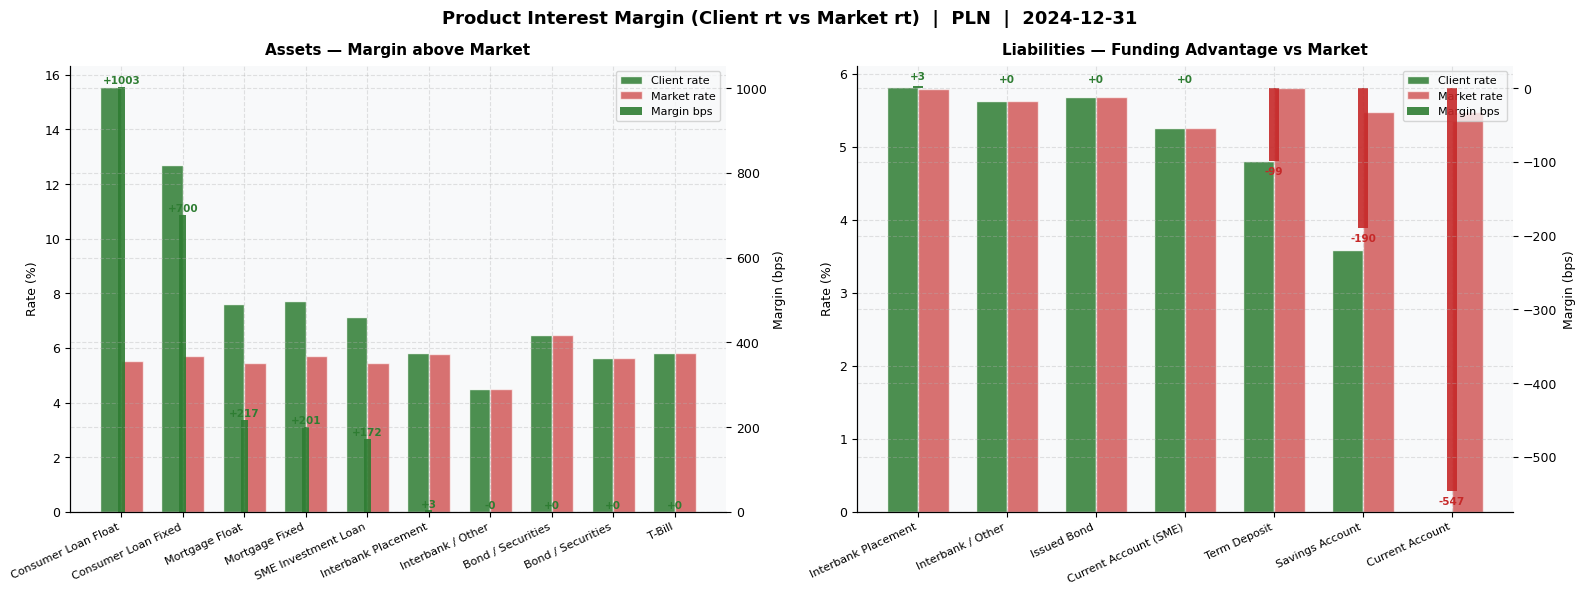

In [9]:
_nii_d = pd.read_sql(
    "SELECT product_code, bs_side, rate_type, tenor_bucket, beh_outstanding, client_rt, fwd_rt, margin "
    "FROM cf.nii_base_scenario WHERE scenario_id='base'",
    ENGINE)

def _wavg(df, val_col, wgt_col):
    w = df[wgt_col].abs()
    return (df[val_col] * w).sum() / w.sum() if w.sum() else 0.0

_bal_lkp = (prod.set_index(['product_code','bs_side'])['balance_amt'].abs().to_dict())

_pm_rows = []
for (pc, side, rt), g in _nii_d.groupby(['product_code','bs_side','rate_type']):
    bal = _bal_lkp.get((pc, side), 0.0)
    c_rt  = _wavg(g, 'client_rt', 'beh_outstanding') * 100
    m_rt  = _wavg(g, 'fwd_rt',    'beh_outstanding') * 100
    marg  = c_rt - m_rt
    contrib = bal * marg / 100 / 1e6   # M PLN annual
    lbl = PROD_LABELS.get(pc, pc)
    _pm_rows.append({'Product': lbl, 'Side': side, 'Type': {'F':'Fixed','V':'Variable','A':'Admin'}.get(rt,rt),
                     'Balance (M)': round(bal/1e6,0), 'Client rt (%)': round(c_rt,2),
                     'Market rt (%)': round(m_rt,2), 'Margin (bps)': round(marg*100,0),
                     'Contribution (M)': round(contrib,1), '_order': 0 if side=='A' else 1})
_pm = pd.DataFrame(_pm_rows).sort_values(['_order','Margin (bps)'], ascending=[True,False]).drop(columns='_order')

# ── Table ──────────────────────────────────────────────────────────────────
hdr6 = '{:<26} {:>2} {:>8} {:>10} {:>12} {:>12} {:>12} {:>16}'.format(
    'Product','S','Type','Bal(M)','Client rt%','Market rt%','Margin bps','Contribution M')
print('\n' + hdr6)
print('-'*105)
for _, r in _pm.iterrows():
    flag = '  <<<' if r['Side']=='A' and r['Margin (bps)'] < 0 else (
           '  <<<' if r['Side']=='L' and r['Margin (bps)'] > 0 else '')
    print('{:<26} {:>2} {:>8} {:>10,.0f} {:>12.2f} {:>12.2f} {:>+12.0f} {:>+16.1f}{}'.format(
        r['Product'], r['Side'], r['Type'], r['Balance (M)'],
        r['Client rt (%)'], r['Market rt (%)'], r['Margin (bps)'], r['Contribution (M)'], flag))
_tot_a = _pm[_pm['Side']=='A']['Contribution (M)'].sum()
_tot_l = _pm[_pm['Side']=='L']['Contribution (M)'].sum()
print('-'*105)
print(f'  Assets total contribution:      {_tot_a:>+8.1f} M PLN / year')
print(f'  Liabilities total contribution: {_tot_l:>+8.1f} M PLN / year')
print(f'  Combined margin value:          {_tot_a+_tot_l:>+8.1f} M PLN / year')

# ── Chart ─────────────────────────────────────────────────────────────────
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(16, 6))
fig6.suptitle(f'Product Interest Margin (Client rt vs Market rt)  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

for ax, side, title in [(ax6a,'A','Assets — Margin above Market'),
                         (ax6b,'L','Liabilities — Funding Advantage vs Market')]:
    _s = _pm[_pm['Side']==side].copy()
    _x = np.arange(len(_s))
    w  = 0.35
    b_c = ax.bar(_x - w/2, _s['Client rt (%)'],  w, color=C_INC, alpha=0.85, label='Client rate', edgecolor='white')
    b_m = ax.bar(_x + w/2, _s['Market rt (%)'],  w, color=C_EXP, alpha=0.65, label='Market rate', edgecolor='white')
    ax2 = ax.twinx()
    marg_vals = _s['Margin (bps)'].tolist()
    mc = [C_INC if v >= 0 else C_EXP for v in marg_vals]
    ax2.bar(_x, marg_vals, 0.12, color=mc, alpha=0.9, label='Margin bps')
    for i, v in enumerate(marg_vals):
        ax2.text(i, v + (8 if v >= 0 else -18), f'{v:+.0f}',
                 ha='center', fontsize=7.5, fontweight='bold',
                 color=C_INC if v >= 0 else C_EXP)
    ax.set_xticks(_x); ax.set_xticklabels(_s['Product'], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Rate (%)'); ax2.set_ylabel('Margin (bps)')
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()


---
## 7. Margin Profile over Time

How the **interest margin** (client rate − market rate) varies across tenor buckets —
i.e. which part of the book has the margin locked in, and which is rolling off soon.

- **High margin in short buckets**: maturing positions repricing soon, margin at risk.
- **High margin in long buckets**: margin locked in for years ahead.
- **NIM per bucket** = weighted asset client rt − weighted liability client rt within that tenor horizon.


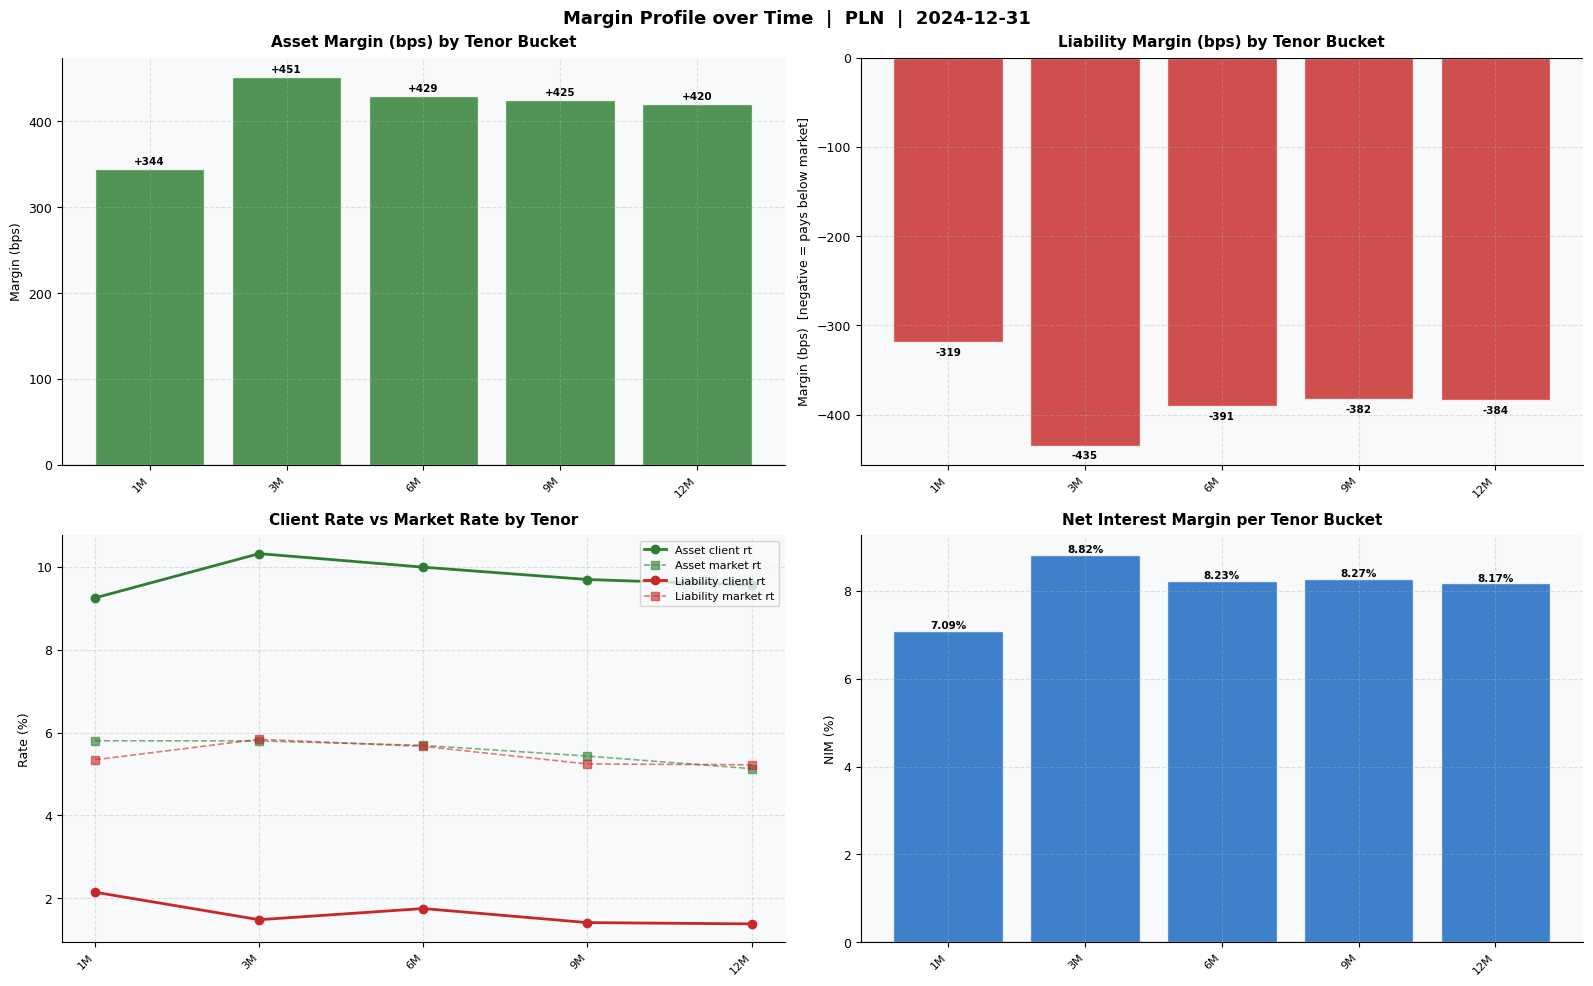


  Margin profile  —  weighted avg by tenor bucket
  Bucket     Asset marg    Liab marg        NIM  Asset bal M   Liab bal M
  ----------------------------------------------------------------------
  1M              +344bps        -319bps      7.09%        6,085        6,508
  3M              +451bps        -435bps      8.82%       15,510       12,764
  6M              +429bps        -391bps      8.23%       19,939       12,662
  9M              +425bps        -382bps      8.27%       18,907       10,817
  12M             +420bps        -384bps      8.17%       18,193       10,247


In [10]:
_mt = pd.read_sql(
    "SELECT bs_side, tenor_bucket, beh_outstanding, client_rt, fwd_rt, margin "
    "FROM cf.nii_base_scenario WHERE scenario_id='base'",
    ENGINE)

def _wavg(df, val_col, wgt_col):
    w = df[wgt_col].abs()
    return (df[val_col] * w).sum() / w.sum() if w.sum() else 0.0

_bkt_rows = []
for (side, bkt), g in _mt.groupby(['bs_side','tenor_bucket']):
    _bkt_rows.append({
        'bs_side': side, 'tenor_bucket': bkt,
        'bal_m':      g['beh_outstanding'].abs().sum() / 1e6,
        'client_rt':  _wavg(g, 'client_rt', 'beh_outstanding') * 100,
        'fwd_rt':     _wavg(g, 'fwd_rt',    'beh_outstanding') * 100,
        'margin_bps': _wavg(g, 'margin',    'beh_outstanding') * 10000,
    })
_bkt = pd.DataFrame(_bkt_rows)
_bkt['_s'] = _bkt['tenor_bucket'].map(tkey)
_bkt = _bkt.sort_values(['bs_side','_s'])

_ba = _bkt[_bkt['bs_side']=='A'].reset_index(drop=True)
_bl = _bkt[_bkt['bs_side']=='L'].reset_index(drop=True)
_common_bkts = sorted(set(_ba['tenor_bucket']) & set(_bl['tenor_bucket']),
                      key=lambda b: tkey(b))
_ba_c = _ba[_ba['tenor_bucket'].isin(_common_bkts)].set_index('tenor_bucket').loc[_common_bkts]
_bl_c = _bl[_bl['tenor_bucket'].isin(_common_bkts)].set_index('tenor_bucket').loc[_common_bkts]
_nim_bkt = _ba_c['client_rt'] - _bl_c['client_rt']

fig7, axes7 = plt.subplots(2, 2, figsize=(16, 10))
fig7.suptitle(f'Margin Profile over Time  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

# Top-left: asset margin bps per bucket
ax = axes7[0,0]
_xa = np.arange(len(_ba))
_ca = [C_INC if v >= 0 else C_EXP for v in _ba['margin_bps']]
ax.bar(_xa, _ba['margin_bps'], color=_ca, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ba['margin_bps']):
    ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xa); ax.set_xticklabels(_ba['tenor_bucket'], rotation=45, ha='right', fontsize=8)
ax.set_title('Asset Margin (bps) by Tenor Bucket'); ax.set_ylabel('Margin (bps)')

# Top-right: liability margin bps per bucket
ax = axes7[0,1]
_xl = np.arange(len(_bl))
_cl = [C_INC if v >= 0 else C_EXP for v in _bl['margin_bps']]
ax.bar(_xl, _bl['margin_bps'], color=_cl, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_bl['margin_bps']):
    ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xl); ax.set_xticklabels(_bl['tenor_bucket'], rotation=45, ha='right', fontsize=8)
ax.set_title('Liability Margin (bps) by Tenor Bucket'); ax.set_ylabel('Margin (bps)  [negative = pays below market]')

# Bottom-left: client_rt vs fwd_rt line chart, assets vs liabilities
ax = axes7[1,0]
_xc = np.arange(len(_common_bkts))
ax.plot(_xc, _ba_c['client_rt'].values, 'o-', color=C_INC, lw=2, label='Asset client rt')
ax.plot(_xc, _ba_c['fwd_rt'].values,    's--', color=C_INC, lw=1.2, alpha=0.6, label='Asset market rt')
ax.plot(_xc, _bl_c['client_rt'].values, 'o-', color=C_EXP, lw=2, label='Liability client rt')
ax.plot(_xc, _bl_c['fwd_rt'].values,    's--', color=C_EXP, lw=1.2, alpha=0.6, label='Liability market rt')
ax.set_xticks(_xc); ax.set_xticklabels(_common_bkts, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rate (%)'); ax.set_title('Client Rate vs Market Rate by Tenor'); ax.legend(fontsize=8)

# Bottom-right: NIM per bucket (asset client_rt - liability client_rt)
ax = axes7[1,1]
_xn = np.arange(len(_nim_bkt))
_cn = [C_NET if v >= 0 else C_EXP for v in _nim_bkt]
ax.bar(_xn, _nim_bkt.values, color=_cn, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_nim_bkt):
    ax.text(i, v + (0.05 if v >= 0 else -0.15), f'{v:.2f}%',
            ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xn); ax.set_xticklabels(_common_bkts, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('NIM (%)'); ax.set_title('Net Interest Margin per Tenor Bucket')

plt.tight_layout(); plt.show()

# Text summary
print('\n  Margin profile  —  weighted avg by tenor bucket')
print(f'  {"Bucket":<8} {"Asset marg":>12} {"Liab marg":>12} {"NIM":>10} {"Asset bal M":>12} {"Liab bal M":>12}')
print('  ' + '-'*70)
for bkt in _common_bkts:
    ra = _ba_c.loc[bkt]; rl = _bl_c.loc[bkt]
    nim = ra['client_rt'] - rl['client_rt']
    print('  {:<8} {:>+11.0f}bps {:>+11.0f}bps {:>9.2f}% {:>12,.0f} {:>12,.0f}'.format(
        bkt, ra['margin_bps'], rl['margin_bps'], nim, ra['bal_m'], rl['bal_m']))


---
## 8. Economic Profit (EP) — Total & Per-Product

**EP = Margin (over FTP) + Fee − Expected Loss − Cost of Capital − OpEx**, the same objective
`bs_optimization/` uses to compare candidate balance sheets. Shown here for the book *as it stands
today* — not as an optimization — split by product so you can see which products are economically
strong vs. weak on a fully-loaded basis, not just on raw interest margin.

Sourced from `optimize_prep/output/product_params.npz` and `ftp_rates.npz` (the same per-product
economics `bs_optimization/` reads), not from SQL like the rest of this report — see the technical
notes for why that's a separate data source. Regenerate both via the `labbank_data_job`/
`optimize_prep_job` Dagster jobs (or `optimize_prep/python_code/opt_prep_workflow.py` +
`build_ftp_rates.py` directly) if you've changed the balance sheet and want fresh EP figures.

Acquisition cost is intentionally excluded — it's a cost of *growing* the balance sheet in the
optimizer, not a steady-state cost, so it's zero for the book as it stands.


  No FTP cache found (optimize_prep/output/ftp_rates.npz) -- Margin will equal client-rate NII until build_ftp_rates.py is run.

  ECONOMIC PROFIT (EP)  |  PLN  |  2024-12-31
  EP = Margin (over FTP) + Fee - EL - CoC - OpEx
  CET1 target 12.0%  |  Cost of capital 10.0%  |  OpEx rate 0.65% of balance
------------------------------------------------------------------
  Margin (over FTP)           +612.1  M PLN
  Fee income                    +7.6  M PLN
  Expected loss (EL)           -45.7  M PLN
  Cost of capital (CoC)        -43.4  M PLN
  Operating cost (OpEx)       -127.7  M PLN
------------------------------------------------------------------
  ECONOMIC PROFIT (EP)        +402.9  M PLN   (+403 bps of total assets)


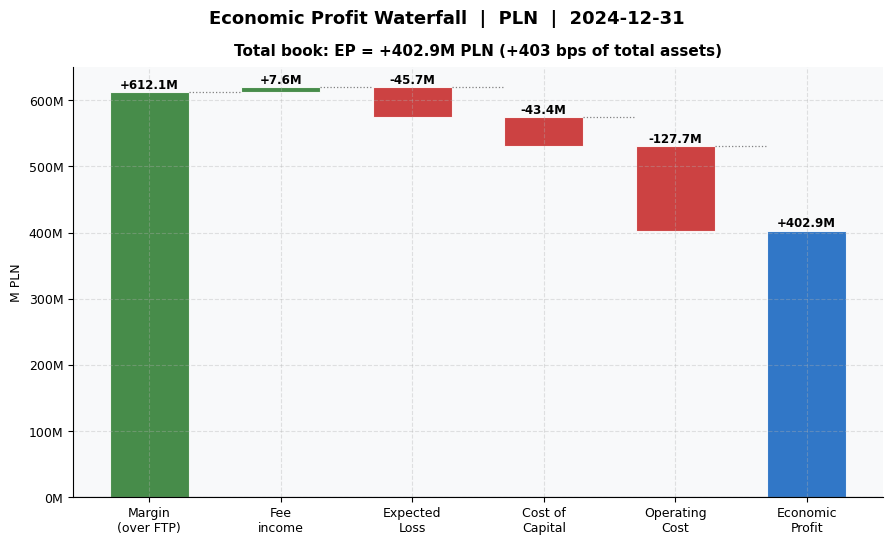


  Product                   Side    Bal(M)  Margin(M)  Fee(M)   EL(M)  CoC(M)  OpEx(M)    EP(M)   EP(bps)
  ------------------------------------------------------------------------------------------------------
  Consumer Loan Float          A     1,800     +277.9    +3.6   -20.2   -16.2    -11.7   +233.3     +1296
  Mortgage Float               A     2,800     +205.5    +1.4    -8.4   -11.8    -18.2   +168.5      +602
  Bond / Securities            A     1,600      +91.0    +0.0    -3.6    -0.0    -10.4    +77.0      +481
  Consumer Loan Fixed          A       600      +78.4    +1.2    -5.4    -5.4     -3.9    +64.9     +1082
  Mortgage Fixed               A     1,000      +73.6    +0.5    -2.0    -4.2     -6.5    +61.4      +614
  Bond / Securities            A       800      +51.9    +0.0    -1.8    -0.0     -5.2    +44.9      +561
  SME Investment Loan          A       600      +41.2    +0.9    -3.1    -5.4     -3.9    +29.7      +495
  T-Bill                       A       400    

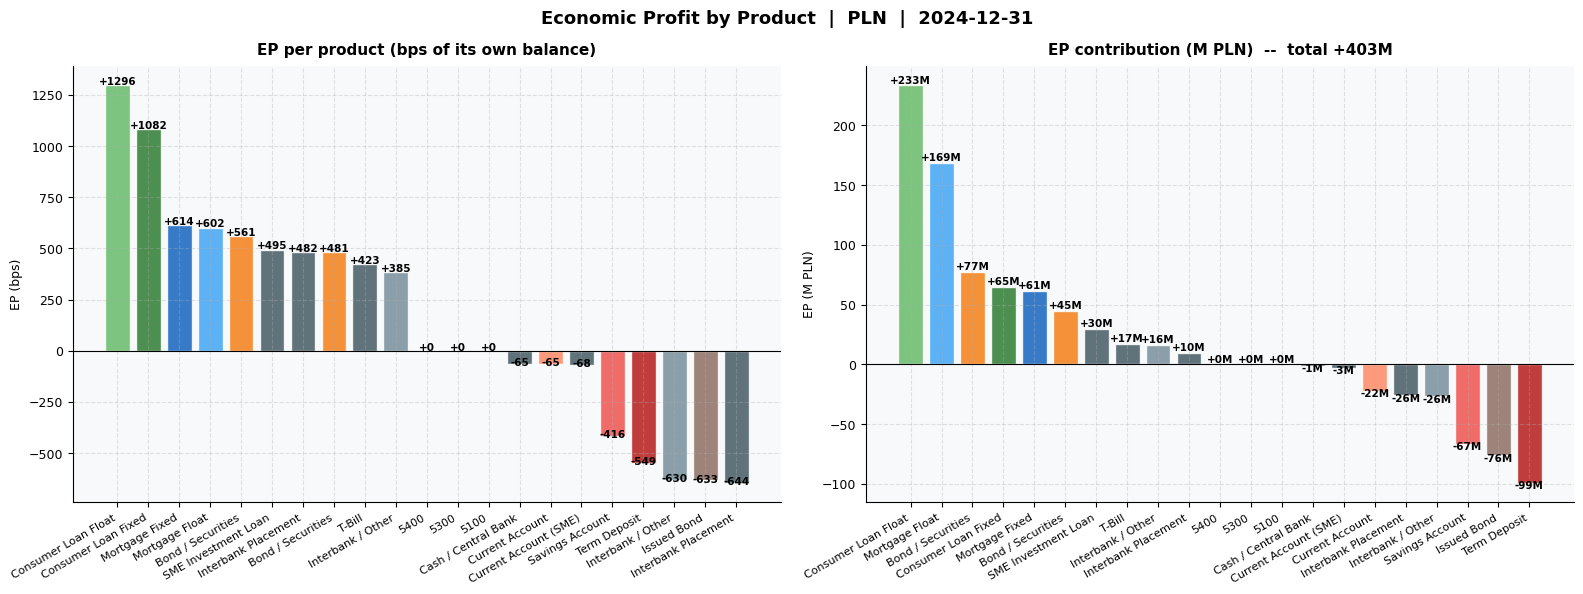

In [11]:
import sys, os

_OPT_PREP_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'optimize_prep', 'python_code'))
if _OPT_PREP_DIR not in sys.path:
    sys.path.insert(0, _OPT_PREP_DIR)
from bs_vector import BalanceSheetParams
from ftp_store import load_ftp_rates, margin_unit_rate

PARAMS_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'optimize_prep', 'output', 'product_params.npz'))
EP_OPEX_RATE = 0.0065   # flat opex rate on non-equity balance -- matches bs_optimizer.py's OPEX_RATE

ep_params = BalanceSheetParams.load(PARAMS_PATH)
ep_ftp_rate = load_ftp_rates(ep_params.cohort_id)
if ep_ftp_rate is None:
    print('  No FTP cache found (optimize_prep/output/ftp_rates.npz) -- Margin will equal '
          'client-rate NII until build_ftp_rates.py is run.')
    ep_ftp_rate = np.zeros_like(ep_params.nii_unit_rate)

ep_margin_rate = margin_unit_rate(ep_params.nii_unit_rate, ep_ftp_rate, ep_params.bs_side)

ep_df = pd.DataFrame({
    'product_code': ep_params.product_code,
    'bs_side':      ep_params.bs_side,
    'balance':      ep_params.balance_arr,
    'margin':       ep_params.balance_arr * ep_margin_rate,
    'fee':          ep_params.balance_arr * ep_params.fee_unit_rate,
    'el':           ep_params.balance_arr * ep_params.el_unit,
    'coc':          ep_params.balance_arr * ep_params.rwa_factor * ep_params.cet1_target * ep_params.coc_rate,
    'opex':         np.where(ep_params.is_equity, 0.0, ep_params.balance_arr * EP_OPEX_RATE),
})
ep_df['ep'] = ep_df['margin'] + ep_df['fee'] - ep_df['el'] - ep_df['coc'] - ep_df['opex']

# ── aggregate cohorts -> one row per product_code ─────────────────────────────
ep_prod = (ep_df.groupby(['product_code', 'bs_side'], as_index=False)
                 .agg(balance=('balance','sum'), margin=('margin','sum'), fee=('fee','sum'),
                      el=('el','sum'), coc=('coc','sum'), opex=('opex','sum'), ep=('ep','sum')))
ep_prod['label']  = ep_prod['product_code'].map(PROD_LABELS).fillna(ep_prod['product_code'])
ep_prod['ep_bps'] = np.where(ep_prod['balance'] != 0, ep_prod['ep'] / ep_prod['balance'].abs() * 10000, 0.0)
ep_prod = ep_prod.sort_values('ep', ascending=False)

_ep_total_bal = ep_prod['balance'].abs().sum()
_tot_margin, _tot_fee = ep_prod['margin'].sum(), ep_prod['fee'].sum()
_tot_el, _tot_coc     = ep_prod['el'].sum(),     ep_prod['coc'].sum()
_tot_opex, _tot_ep    = ep_prod['opex'].sum(),   ep_prod['ep'].sum()

print(f'\n{"="*66}')
print(f'  ECONOMIC PROFIT (EP)  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'{"="*66}')
print(f'  EP = Margin (over FTP) + Fee - EL - CoC - OpEx')
print(f'  CET1 target {ep_params.cet1_target*100:.1f}%  |  Cost of capital {ep_params.coc_rate*100:.1f}%'
      f'  |  OpEx rate {EP_OPEX_RATE*100:.2f}% of balance')
print(f'{"-"*66}')
print(f'  Margin (over FTP)        {_tot_margin/1e6:>+9.1f}  M PLN')
print(f'  Fee income               {_tot_fee/1e6:>+9.1f}  M PLN')
print(f'  Expected loss (EL)       {-_tot_el/1e6:>+9.1f}  M PLN')
print(f'  Cost of capital (CoC)    {-_tot_coc/1e6:>+9.1f}  M PLN')
print(f'  Operating cost (OpEx)    {-_tot_opex/1e6:>+9.1f}  M PLN')
print(f'{"-"*66}')
print(f'  ECONOMIC PROFIT (EP)     {_tot_ep/1e6:>+9.1f}  M PLN   '
      f'({_tot_ep/total_assets*10000:>+.0f} bps of total assets)')
print(f'{"="*66}')

# ── Waterfall: book-level EP bridge (Margin -> Fee -> -EL -> -CoC -> -OpEx -> EP) ──
_ep_components = [
    ('Margin\n(over FTP)', _tot_margin/1e6, C_INC),
    ('Fee\nincome',        _tot_fee/1e6,     C_INC),
    ('Expected\nLoss',     -_tot_el/1e6,     C_EXP),
    ('Cost of\nCapital',   -_tot_coc/1e6,    C_EXP),
    ('Operating\nCost',    -_tot_opex/1e6,   C_EXP),
]
_wf2_labels, _wf2_heights, _wf2_bots, _wf2_cols = [], [], [], []
_running = 0.0
for _lbl, _val, _col in _ep_components:
    _wf2_labels.append(_lbl)
    _wf2_bots.append(_running if _val >= 0 else _running + _val)
    _wf2_heights.append(abs(_val))
    _wf2_cols.append(_col)
    _running += _val
_wf2_labels.append('Economic\nProfit')
_wf2_bots.append(0.0)
_wf2_heights.append(_running)
_wf2_cols.append(C_NET)

fig8c, ax8c = plt.subplots(figsize=(9, 5.5))
fig8c.suptitle(f'Economic Profit Waterfall  |  {CCY}  |  {REPORT_DATE.date()}',
               fontsize=13, fontweight='bold')
_x8c = np.arange(len(_wf2_labels))
bars8c = ax8c.bar(_x8c, _wf2_heights, bottom=_wf2_bots, color=_wf2_cols,
                   alpha=0.88, edgecolor='white', linewidth=0.8, width=0.6)
for i, (bar, (_lbl, _val, _col)) in enumerate(zip(bars8c, _ep_components + [('', _running, C_NET)])):
    top = bar.get_y() + bar.get_height()
    ax8c.text(bar.get_x() + bar.get_width()/2, top + 1.5, f'{_val:+.1f}M',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    if i < len(_wf2_labels) - 1:
        ax8c.plot([bar.get_x() + bar.get_width(), bar.get_x() + bar.get_width() + 0.4],
                  [top, top], color='grey', lw=0.9, ls=':')
ax8c.set_xticks(_x8c); ax8c.set_xticklabels(_wf2_labels, fontsize=9)
ax8c.axhline(0, color='black', lw=0.8)
ax8c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax8c.set_ylabel('M PLN'); ax8c.set_title(f'Total book: EP = {_tot_ep/1e6:+.1f}M PLN '
                                          f'({_tot_ep/total_assets*10000:+.0f} bps of total assets)')
plt.tight_layout(); plt.show()

print(f'\n  {"Product":<25}{"Side":>5} {"Bal(M)":>9} {"Margin(M)":>10} {"Fee(M)":>7} '
      f'{"EL(M)":>7} {"CoC(M)":>7} {"OpEx(M)":>8} {"EP(M)":>8} {"EP(bps)":>9}')
print('  ' + '-'*102)
for _, r in ep_prod.iterrows():
    print(f'  {r["label"]:<25}{r["bs_side"]:>5} {r["balance"]/1e6:>9,.0f} {r["margin"]/1e6:>+10.1f} '
          f'{r["fee"]/1e6:>+7.1f} {-r["el"]/1e6:>+7.1f} {-r["coc"]/1e6:>+7.1f} {-r["opex"]/1e6:>+8.1f} '
          f'{r["ep"]/1e6:>+8.1f} {r["ep_bps"]:>+9.0f}')
print('  ' + '-'*102)
print(f'  {"TOTAL":<25}{"":>5} {_ep_total_bal/1e6:>9,.0f} {_tot_margin/1e6:>+10.1f} {_tot_fee/1e6:>+7.1f} '
      f'{-_tot_el/1e6:>+7.1f} {-_tot_coc/1e6:>+7.1f} {-_tot_opex/1e6:>+8.1f} {_tot_ep/1e6:>+8.1f} '
      f'{(_tot_ep/_ep_total_bal*10000):>+9.0f}')
print('\n  Note: acquisition cost is excluded -- it only applies when comparing to a')
print('  rebalanced target mix in the optimizer, not to the book as it stands today.')

# ── Chart: EP by product ──────────────────────────────────────────────────────
fig8, (ax8a, ax8b) = plt.subplots(1, 2, figsize=(16, 6))
fig8.suptitle(f'Economic Profit by Product  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

_ep_bps_sorted = ep_prod.sort_values('ep_bps', ascending=False)
_x8a = np.arange(len(_ep_bps_sorted))
_c8a = [PRODUCT_COLORS.get(lb, C_GR) for lb in _ep_bps_sorted['label']]
ax8a.bar(_x8a, _ep_bps_sorted['ep_bps'], color=_c8a, alpha=0.85, edgecolor='white')
ax8a.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ep_bps_sorted['ep_bps']):
    ax8a.text(i, v + (3 if v >= 0 else -8), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax8a.set_xticks(_x8a); ax8a.set_xticklabels(_ep_bps_sorted['label'], rotation=30, ha='right', fontsize=8)
ax8a.set_title('EP per product (bps of its own balance)'); ax8a.set_ylabel('EP (bps)')

_ep_m_sorted = ep_prod.sort_values('ep', ascending=False)
_x8b = np.arange(len(_ep_m_sorted))
_c8b = [PRODUCT_COLORS.get(lb, C_GR) for lb in _ep_m_sorted['label']]
ax8b.bar(_x8b, _ep_m_sorted['ep']/1e6, color=_c8b, alpha=0.85, edgecolor='white')
ax8b.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ep_m_sorted['ep']/1e6):
    ax8b.text(i, v + (2 if v >= 0 else -5), f'{v:+.0f}M', ha='center', fontsize=7.5, fontweight='bold')
ax8b.set_xticks(_x8b); ax8b.set_xticklabels(_ep_m_sorted['label'], rotation=30, ha='right', fontsize=8)
ax8b.set_title(f'EP contribution (M PLN)  --  total {_tot_ep/1e6:+.0f}M'); ax8b.set_ylabel('EP (M PLN)')

plt.tight_layout(); plt.show()
